## Final Project Submission

Please fill out:
* Student name:
* Student pace: self paced / part time / full time
* Scheduled project review date/time:
* Instructor name:
* Blog post URL:


In [1]:
# Your code here - remember to use markdown cells for comments as well!

### As major entertainment companies continue to create original video content, our organization is entering the movie industry with the aim of launching or working with the best film studio. However, we lack prior experience in film production and distribution. The goal of this project is to use data-driven insights to guide our entry strategy by understanding what types of films perform best at the box office.

### Using the `bom.movie_gross` dataset, this exploratory data analysis investigates box office revenue trends across different studios and film characteristics. We then performed certain hypothesis and staitstical tests to confirm our findings.



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3


In [3]:
box_office = pd.read_csv('/content/bom.movie_gross.csv.gz', delimiter=',')

In [4]:
box_office.head()

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010


### Data checking and cleaning


In [5]:
def explore_dataframe(df, name="DataFrame"):
    print(f"\n===== {name} Overview =====")

    print("\nShape:")
    print(df.shape)

    print("\nInfo:")
    print("-" * 40)
    df.info()

    print("\nDescription:")
    print("-" * 40)
    print(df.describe(include='all'))

In [6]:
explore_dataframe(box_office, name="Box Office")


===== Box Office Overview =====

Shape:
(3387, 5)

Info:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   object 
 4   year            3387 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 132.4+ KB

Description:
----------------------------------------
            title studio  domestic_gross foreign_gross         year
count        3387   3382    3.359000e+03          2037  3387.000000
unique       3386    257             NaN          1204          NaN
top     Bluebeard    IFC             NaN       1200000          NaN
freq            2    166             NaN            23          NaN
mean          NaN    

In [7]:
# Calculate missing percentages
missing_percentage = (box_office.isnull().sum() / len(box_office)) * 100

# Display missing values sorted in descending order
print(missing_percentage.sort_values(ascending=False))

foreign_gross     39.858282
domestic_gross     0.826690
studio             0.147623
title              0.000000
year               0.000000
dtype: float64


In [8]:
# Convert 'foreign_gross' to numeric, handling errors
box_office['foreign_gross'] = pd.to_numeric(box_office['foreign_gross'], errors='coerce')

# Calculate the median of 'foreign_gross'
median_foreign_gross = box_office['foreign_gross'].median()

# Fill missing values in 'foreign_gross' with the median, avoiding chained assignment
box_office.loc[:, 'foreign_gross'] = box_office['foreign_gross'].fillna(median_foreign_gross)

# Fill missing values in 'domestic_gross' with the median
domestic_gross_median = box_office['domestic_gross'].median()
box_office['domestic_gross'].fillna(domestic_gross_median, inplace=True)

# Fill missing values in 'studio' with the mode
studio_mode = box_office['studio'].mode()[0]  # Get the most frequent value (mode)
box_office['studio'].fillna(studio_mode, inplace=True)

<ipython-input-8-1439993ab643>:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  box_office['domestic_gross'].fillna(domestic_gross_median, inplace=True)
<ipython-input-8-1439993ab643>:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

In [9]:
# Fill missing values in 'domestic_gross' with the median, avoiding chained assignment
box_office.loc[:, 'domestic_gross'] = box_office['domestic_gross'].fillna(domestic_gross_median)

# Fill missing values in 'studio' with the mode, avoiding chained assignment
box_office.loc[:, 'studio'] = box_office['studio'].fillna(studio_mode)

In [10]:
box_office.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3387 non-null   object 
 2   domestic_gross  3387 non-null   float64
 3   foreign_gross   3387 non-null   float64
 4   year            3387 non-null   int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 132.4+ KB


In [11]:
# Calculate total box office and add as a new column
box_office['total_gross'] = box_office['domestic_gross'] + box_office['foreign_gross']

In [12]:
# Calculate missing percentages
missing_percentage = (box_office.isnull().sum() / len(box_office)) * 100

# Display missing values sorted in descending order
print(missing_percentage.sort_values(ascending=False))

title             0.0
studio            0.0
domestic_gross    0.0
foreign_gross     0.0
year              0.0
total_gross       0.0
dtype: float64


In [13]:
# Check for duplicates and create a boolean mask
duplicates_mask = box_office.duplicated()

# Get the number of duplicates
num_duplicates = duplicates_mask.sum()

# Print the number of duplicates
print(f"Number of duplicate rows: {num_duplicates}")

# If you want to view the duplicate rows:
duplicate_rows = box_office[duplicates_mask]
print("\nDuplicate Rows:")
print(duplicate_rows)


Number of duplicate rows: 0

Duplicate Rows:
Empty DataFrame
Columns: [title, studio, domestic_gross, foreign_gross, year, total_gross]
Index: []


In [14]:
box_office.columns

Index(['title', 'studio', 'domestic_gross', 'foreign_gross', 'year',
       'total_gross'],
      dtype='object')

### Begin EDA and Visualisation

In [15]:
box_office.describe()

,domestic_gross,foreign_gross,year,total_gross
count,3.387000e+03,3.387000e+03,3387.000000,3.387000e+03
mean,2.851978e+07,5.259091e+07,2013.958075,8.111069e+07
std,6.675093e+07,1.100108e+08,2.478141,1.676347e+08
min,1.000000e+02,6.000000e+02,2010.000000,4.900000e+03
25%,1.225000e+05,1.175000e+07,2012.000000,1.890745e+07
50%,1.400000e+06,1.890000e+07,2014.000000,1.953300e+07
75%,2.750000e+07,2.915000e+07,2016.000000,6.180000e+07
max,9.367000e+08,9.605000e+08,2018.000000,1.518900e+09


Find the average total,foreign and domestic gross

In [16]:
# Calculate the mean of total_gross, domestic_gross, and foreign_gross
mean_total_gross = box_office['total_gross'].mean()
mean_domestic_gross = box_office['domestic_gross'].mean()
mean_foreign_gross = box_office['foreign_gross'].mean()

# Print the mean values
print(f"Mean Total Gross: {mean_total_gross}")
print(f"Mean Domestic Gross: {mean_domestic_gross}")
print(f"Mean Foreign Gross: {mean_foreign_gross}")

Mean Total Gross: 81110688.56303513
Mean Domestic Gross: 28519779.62208444
Mean Foreign Gross: 52590908.94095069


<ipython-input-17-4a6d57de2a14>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_gross_hundreds_millions', y='studio', data=top_10_studios, palette='viridis')


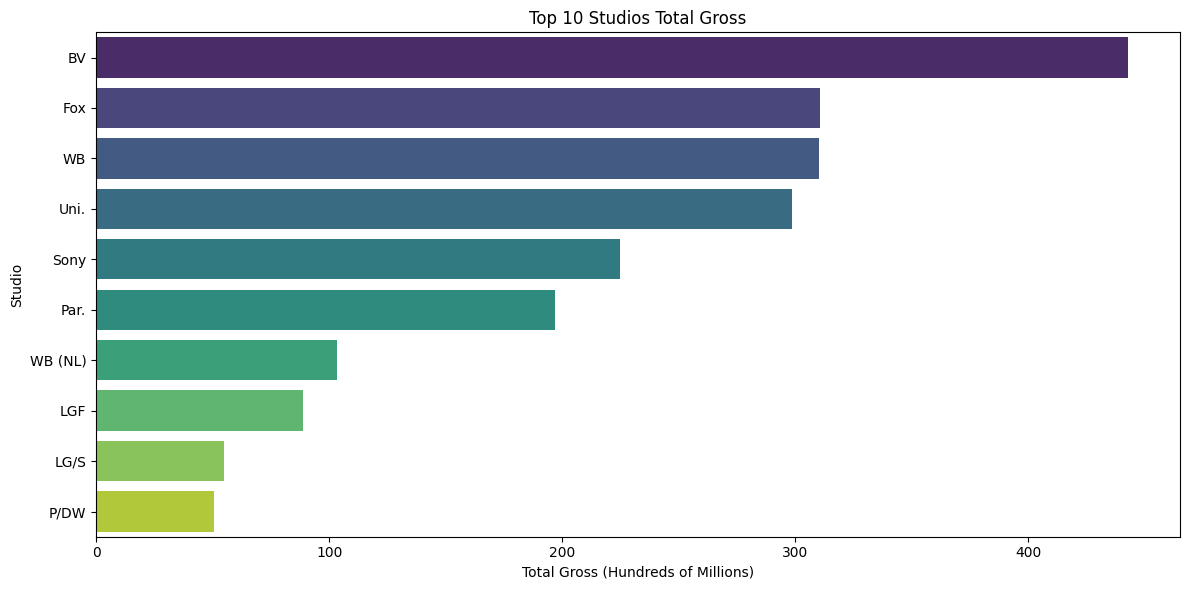

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort by mean of 'total_gross' and select the top 10
top_10_studios = box_office.groupby('studio')['total_gross'].sum().sort_values(ascending=False).head(10).reset_index()

# Divide 'total_gross' by 100,000,000 to get hundreds of millions
top_10_studios['total_gross_hundreds_millions'] = top_10_studios['total_gross'] / 100000000

# Create the bar plot with reversed axes and color palette
plt.figure(figsize=(12, 6))  # Adjust figure size if needed
sns.barplot(x='total_gross_hundreds_millions', y='studio', data=top_10_studios, palette='viridis')
plt.ylabel("Studio")
plt.xlabel("Total Gross (Hundreds of Millions)")
plt.title("Top 10 Studios Total Gross")
plt.tight_layout()
plt.show()


<ipython-input-18-406ca78b30e0>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='foreign_gross_hundreds_millions', y='studio', data=top_15_foreign, palette='plasma')


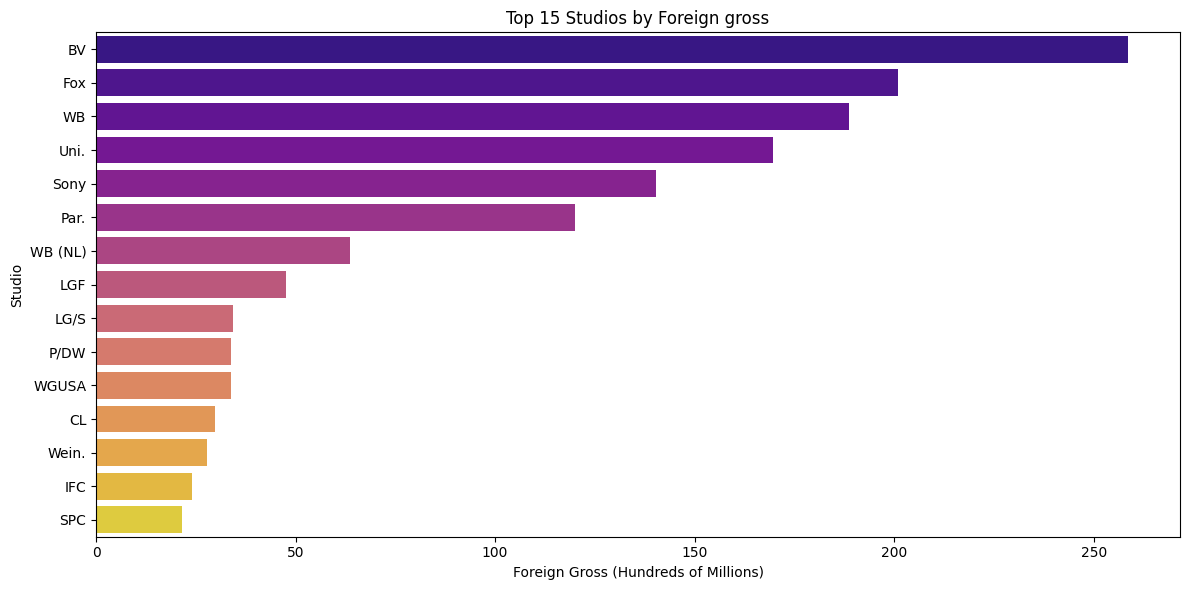

In [18]:
# Sort by mean of 'foreign_gross' and select the top 15
top_15_foreign = box_office.groupby('studio')['foreign_gross'].sum().sort_values(ascending=False).head(15).reset_index()

# Divide 'foreign_gross' by 100,000,000 to get hundreds of millions
top_15_foreign['foreign_gross_hundreds_millions'] = top_15_foreign['foreign_gross'] / 100000000

# Create the bar plot with reversed axes and color palette
plt.figure(figsize=(12, 6))  # Adjust figure size if needed
sns.barplot(x='foreign_gross_hundreds_millions', y='studio', data=top_15_foreign, palette='plasma')
plt.ylabel("Studio")  # Use 'studio' for y-axis label
plt.xlabel("Foreign Gross (Hundreds of Millions)")  # Update x-axis label
plt.title("Top 15 Studios by Foreign gross")
plt.tight_layout()
plt.show()

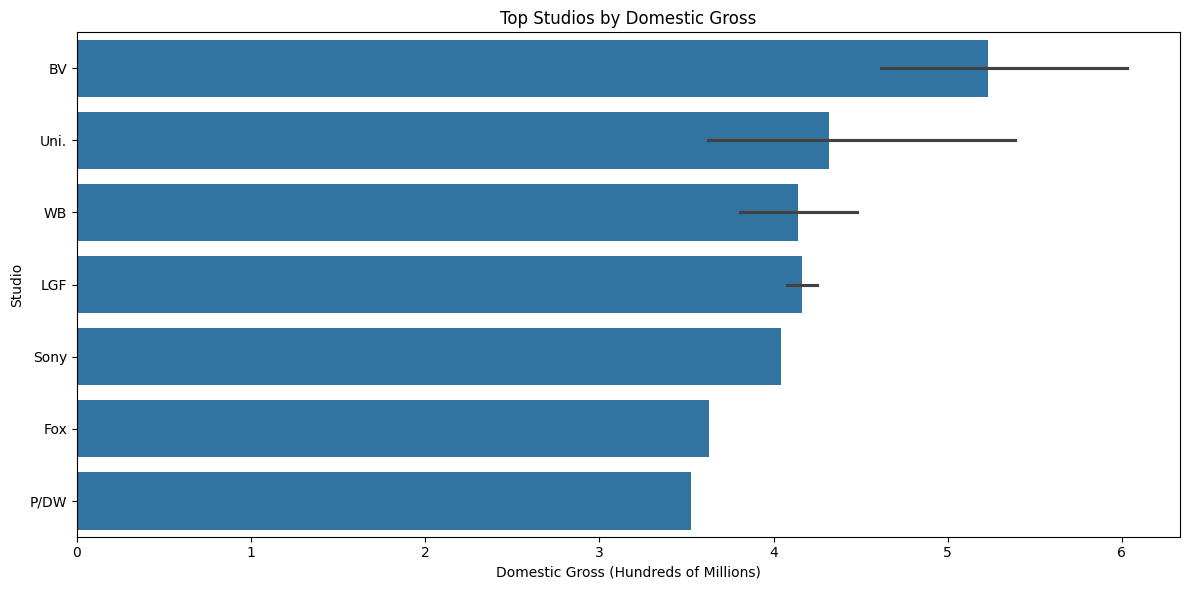

In [19]:
# Sort by 'domestic_gross' and select the top 30
top_30_domestic = box_office.sort_values(by='domestic_gross', ascending=False).head(30)

# Divide 'domestic_gross' by 100,000,000 to get hundreds of millions
top_30_domestic['domestic_gross_hundreds_millions'] = top_30_domestic['domestic_gross'] / 100000000

# Create the bar plot with reversed axes and color palette
plt.figure(figsize=(12, 6))  # Adjust figure size if needed
sns.barplot(x='domestic_gross_hundreds_millions', y='studio', data=top_30_domestic)
plt.ylabel("Studio")  # Use 'studio' for y-axis label
plt.xlabel("Domestic Gross (Hundreds of Millions)")  # Update x-axis label
plt.title("Top Studios by Domestic Gross")
plt.tight_layout()
plt.show()

### Try find a relationship between Domestic and Foreign Gross

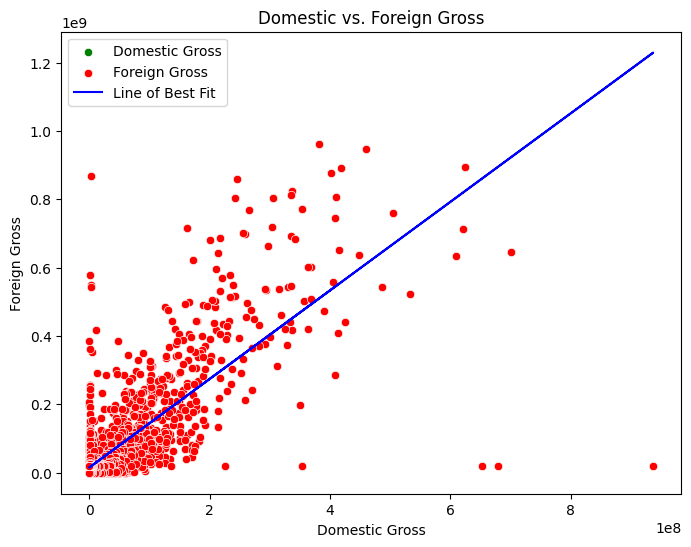

In [20]:
# Create the scatter plot with specified colors
plt.figure(figsize=(8, 6))
sns.scatterplot(x='domestic_gross', y='foreign_gross', data=box_office,
                color='green', label='Domestic Gross')
sns.scatterplot(x='domestic_gross', y='foreign_gross', data=box_office,
                color='red', label='Foreign Gross')

# Calculate and plot the line of best fit
x = box_office['domestic_gross']
y = box_office['foreign_gross']
m, b = np.polyfit(x, y, 1)  # Calculate slope (m) and y-intercept (b)
plt.plot(x, m*x + b, color='blue', label='Line of Best Fit')  # Plot the line

plt.title('Domestic vs. Foreign Gross')
plt.xlabel('Domestic Gross')
plt.ylabel('Foreign Gross')
plt.legend()
plt.show()

 There is a general positive correlation between domestic and foreign gross. This means that movies that perform well domestically tend to also perform well in foreign markets, and vice versa.
 The correlation appears to be relatively strong, as the points are clustered around the line of best fit, suggesting a clear relationship between the two variables.

A limitation to this is while most movies follow the general trend, there are some outliers. Some movies have high domestic gross but relatively low foreign gross, while others have high foreign gross but lower domestic gross

### Group by 'studio' and count the number of movies

In [21]:
# Group by 'studio' and count the number of movies
studio_counts = box_office.groupby('studio')['title'].count().sort_values(ascending=False)

# Get the top 10 studios
top_15_studios = studio_counts.head(15)
top_15_studios


,title
studio,
IFC,171
Uni.,147
WB,140
Magn.,136
Fox,136
SPC,123
Sony,110
BV,106
LGF,103


### Now let’s perform an ANOVA (Analysis of Variance) test. This is useful when comparing more than two groups — in this case, comparing average total gross across multiple studios.This determines if there's a statistically significant difference in total gross revenue across different movie studios.

In [22]:
from scipy.stats import f_oneway

# Select top 10 studios for ANOVA test - (Analysis of Variance) test.
top_10_studios = box_office.groupby('studio')['title'].count().sort_values(ascending=False).head(10).index
filtered_data = box_office[box_office['studio'].isin(top_10_studios)]

# Prepare data for ANOVA
groups = [group['total_gross'].values for name, group in filtered_data.groupby('studio')]

# Run the ANOVA test
f_stat, p_value = f_oneway(*groups)

# Print results
print(f"F-statistic: {f_stat}")
print(f"P-value: {p_value}")

F-statistic: 48.557719582460166
P-value: 1.5409192913070301e-75


F-statistic: 48.557719582460166

The F-statistic measures the variance between the means of the groups (studios in your case) compared to the variance within the groups.
A larger F-statistic indicates a greater difference between the group means.
In your case, the F-statistic is relatively large (48.56), suggesting there's a significant difference in the mean total_gross between the top 10 studios.

The p-value represents the probability of observing the obtained results (or more extreme results) if there were no real difference between the group means.
A smaller p-value indicates stronger evidence against the null hypothesis (that there's no difference between the group means).
In your case, the p-value is extremely small (close to 0), which is much lower than the typical significance level of 0.05.




### Perform a hypothesis test using your movie box office data. The test will check whether top studios  earn significantly more than other studios in terms of total_gross

In [23]:
#PERFRM 2 SAMPLE T TEST
from scipy.stats import ttest_ind

# Define top studios (can adjust list based on your EDA)
top_studios = ['WB', 'BV', 'Fox', 'Sony', 'LGF']  # Example list
box_office['studio'] = box_office['studio'].astype(str)
box_office['total_gross'] = pd.to_numeric(box_office['total_gross'], errors='coerce')

# Create two groups
top_group = box_office[box_office['studio'].isin(top_studios)]['total_gross'].dropna()
other_group = box_office[~box_office['studio'].isin(top_studios)]['total_gross'].dropna()

# Perform independent two-sample t-test
t_stat, p_value = ttest_ind(top_group, other_group, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

# Interpretation
if p_value < 0.05:
    print("Reject the null hypothesis: Top studios earn significantly more.")
else:
    print("Fail to reject the null hypothesis: No significant difference found.")


T-statistic: 15.623108560101251
P-value: 9.228421780874135e-47
Reject the null hypothesis: Top studios earn significantly more.


The null hypothesis assumes that the average total gross revenue generated by movies from the top 10 studios is essentially the same. Any observed differences are due to random chance or sampling variability.

The alternative hypothesis proposes that the average total gross revenue generated by movies from the top 10 studios is not the same. There are real, underlying differences in performance between these studios.

Reject the null hypothesis: Based on the very small p-value, you can reject the null hypothesis. This means there's strong evidence to suggest that there's a statistically significant difference in the mean total_gross between the top 10 studios.

### Check for coorelation coefficient OF DOMESTIC and FOREIGN Gross

In [24]:
correlation = box_office['domestic_gross'].corr(box_office['foreign_gross'])
print(f"Correlation: {correlation}")

Correlation: 0.7859759148901354


correlation coefficient of 0.7859759148901354 suggests a strong positive correlation between domestic gross and foreign gross for movies in your dataset.

positive sign indicates that as domestic gross increases, foreign gross also tends to increase, and vice versa.

 correlation suggests that movies that perform well domestically (in terms of box office revenue) are also likely to perform well in foreign markets, and movies that don't do well domestically are likely to underperform internationally as well.

### Attempt regression analysis to model r/ship btn dependent and independent var

In [25]:
#re gression analysis to model r/ship btn dependent and independent var

# Extract year from the 'year' column to create 'release_year' column
box_office['release_year'] = box_office['year']


import statsmodels.formula.api as smf

# Assuming 'release_year' is a column in your 'box_office' DataFrame
# And 'total_gross' is the target variable
model = smf.ols('total_gross ~ release_year', data=box_office).fit()

# Print the model summary to see the results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            total_gross   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     7.055
Date:                Thu, 01 May 2025   Prob (F-statistic):            0.00794
Time:                        08:53:45   Log-Likelihood:                -68943.
No. Observations:                3387   AIC:                         1.379e+05
Df Residuals:                    3385   BIC:                         1.379e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept    -6.132e+09   2.34e+09     -2.621   

R-squared: 0.002
This value is very low, indicating that only 0.2% of the variance in total_gross is explained by release_year. This means the model isn't very good at predicting total gross based solely on the release year.


F-statistic: 7.055 This statistic tests the overall significance of the model. The associated p-value (0.00794) is less than 0.05, indicating that the model is statistically significant. This means that release_year does have some effect on total_gross, although it's not a strong effect.

There is a statistically significant but weak positive relationship between the release year and the total gross of a movie. This means that newer movies tend to have slightly higher total gross revenue, but the release year alone is not a strong predictor of a movie's success.